# LIBRARIES 

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import  LogisticRegression
from sklearn.metrics import  accuracy_score
from mlxtend.plotting import  plot_decision_regions
import pickle

In [2]:
data =pd.read_csv('placement.csv')

In [3]:
data.sample(5)

,Unnamed: 0,cgpa,iq,placement
20,20,6.6,120.0,1
50,50,3.5,233.0,0
78,78,6.1,81.0,0
98,98,6.3,103.0,1
6,6,5.7,143.0,0


In [4]:
data_df=data.iloc[:,1:]

In [5]:
data_df.sample(5)

,cgpa,iq,placement
49,5.4,135.0,0
78,6.1,81.0,0
13,6.4,116.0,1
96,4.4,42.0,0
0,6.8,123.0,1


In [6]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [7]:
data_df.describe()

,cgpa,iq,placement
count,100.000000,100.000000,100.000000
mean,5.991000,123.580000,0.500000
std,1.143634,39.944198,0.502519
min,3.300000,37.000000,0.000000
25%,5.075000,101.500000,0.000000
50%,6.000000,127.500000,0.500000
75%,6.900000,149.000000,1.000000
max,8.500000,233.000000,1.000000


# EDA 

<Axes: xlabel='cgpa', ylabel='iq'>

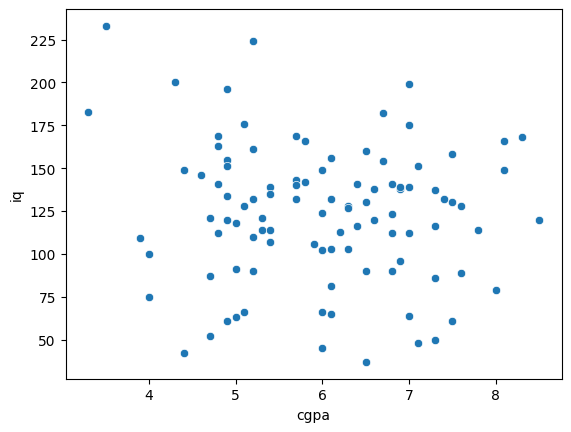

In [9]:
sns.scatterplot(x=data_df['cgpa'],y=data_df['iq'])

<Axes: xlabel='cgpa', ylabel='iq'>

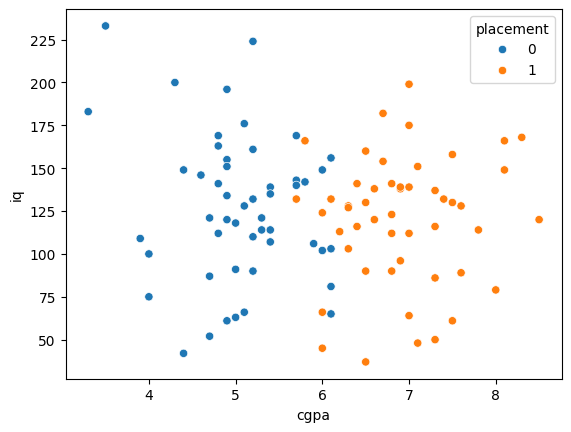

In [10]:
sns.scatterplot(x=data_df['cgpa'],y=data_df['iq'],hue=data_df['placement'])

<Axes: ylabel='cgpa'>

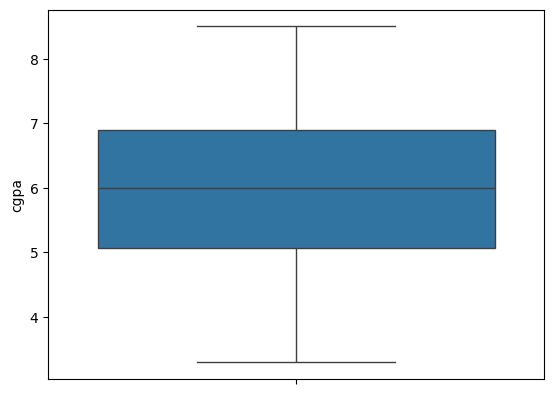

In [11]:
sns.boxplot(data_df['cgpa'])

<Axes: ylabel='iq'>

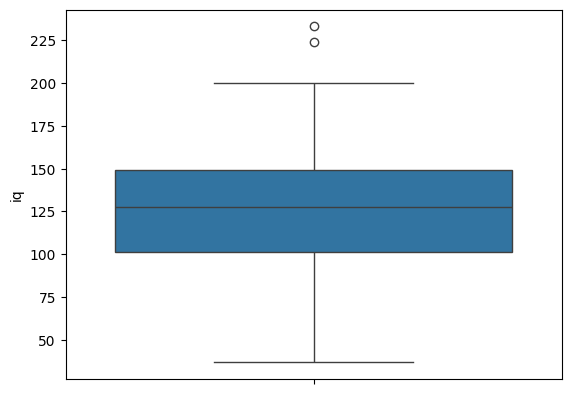

In [12]:
sns.boxplot(data_df['iq'])

In [13]:
cordata=data_df.corr(numeric_only=True)

<Axes: >

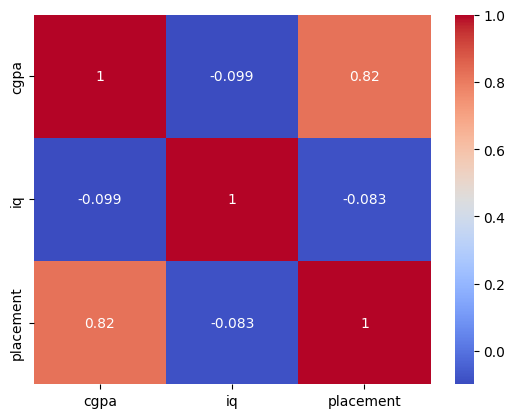

In [14]:
sns.heatmap(cordata,annot=True,cmap="coolwarm")

# EXTRACT OUTPUTS

In [15]:
data_df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [17]:
x=data_df.iloc[:,0:2]
y=data_df.iloc[:,-1]

In [18]:
print(x)
x.shape

    cgpa     iq
0    6.8  123.0
1    5.9  106.0
2    5.3  121.0
3    7.4  132.0
4    5.8  142.0
..   ...    ...
95   4.3  200.0
96   4.4   42.0
97   6.7  182.0
98   6.3  103.0
99   6.2  113.0

[100 rows x 2 columns]


(100, 2)

In [19]:
print(y)
y.shape

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64


(100,)

# TRAIN TEST SPLITING

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [21]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(80, 2)
(20, 2)
(80,)
(20,)


In [22]:
print(x_test)

    cgpa     iq
42   7.6   89.0
82   6.5   37.0
94   4.7   52.0
76   4.9  155.0
35   6.8   90.0
14   6.1  103.0
97   6.7  182.0
50   3.5  233.0
22   4.9  120.0
80   4.9  196.0
65   8.1  166.0
24   4.7  121.0
93   6.8  112.0
96   4.4   42.0
13   6.4  116.0
0    6.8  123.0
36   5.7  140.0
40   4.9  134.0
71   6.1  132.0
79   6.5   90.0


# SCALING

In [23]:
scaler=StandardScaler()

In [25]:
Xtrain=scaler.fit_transform(x_train)

In [ ]:
xtest=scaler.transform(x_test)

In [27]:
print(Xtrain)

[[-7.30826783e-01  2.68642536e+00]
 [-5.53924687e-01  4.01535747e-01]
 [-7.30826783e-01  9.92918940e-01]
 [ 8.61292079e-01  4.01535747e-01]
 [-9.07728879e-01 -1.62966391e-01]
 [ 7.72841031e-01 -7.54349584e-01]
 [-1.08463097e+00  4.55297856e-01]
 [ 5.95938935e-01  8.04751561e-01]
 [ 1.39199837e+00  1.05844151e-01]
 [ 7.72841031e-01  3.74654693e-01]
 [-1.79223936e+00 -1.31885172e+00]
 [-5.53924687e-01 -2.70490608e-01]
 [-1.08463097e+00  1.04668105e+00]
 [ 8.61292079e-01 -3.24252717e-01]
 [-5.53924687e-01 -4.58657988e-01]
 [-2.88571544e-01  5.09059964e-01]
 [-6.42375735e-01 -8.23232286e-02]
 [ 6.52326478e-02  8.58513669e-01]
 [ 1.21509627e+00  2.13368368e-01]
 [-9.07728879e-01 -8.88754855e-01]
 [ 2.42134744e-01  7.89630968e-02]
 [ 3.30585791e-01  4.55297856e-01]
 [ 4.19036839e-01  1.59606259e-01]
 [-9.07728879e-01 -1.64142437e+00]
 [ 2.42134744e-01 -5.66182205e-01]
 [ 7.72841031e-01  4.01535747e-01]
 [ 2.18805780e+00 -1.09204283e-01]
 [ 1.30354732e+00 -1.69518648e+00]
 [-1.08463097e+00 -3

# MODEL TRAINING 

In [28]:
LR=LogisticRegression()

In [29]:
model=LR.fit(Xtrain,y_train)

In [30]:
y_pred=model.predict(xtest)

In [31]:
y_test

42    1
82    1
94    0
76    0
35    1
14    0
97    1
50    0
22    0
80    0
65    1
24    0
93    1
96    0
13    1
0     1
36    0
40    0
71    1
79    1
Name: placement, dtype: int64

In [32]:
accuracy_score(y_test,y_pred)

0.95

<Axes: >

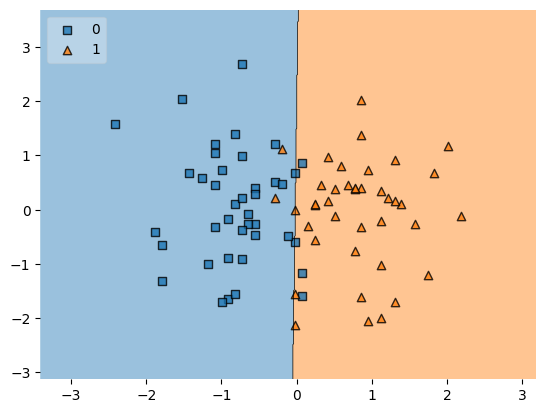

In [36]:
plot_decision_regions(Xtrain,y_train.values,clf=model,legend=2)

In [53]:
def com_Data(data_new):
    data_new = np.array(data_new, dtype=float)
    data_scaled = scaler.transform(data_new)
    pred = model.predict(data_scaled)
    return "placed" if pred[0] == 1 else "not placed"

print(com_Data([[1, 2.0]]))



not placed


In [50]:
pickle.dump(model,open("placement.pkl",mode='wb'))

In [51]:
pickle.dump(scaler,open("scaler.pkl",mode='wb'))